In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Kathmandu AQI dataset - hourly readings for 2023
df = pd.read_csv("ktmaqi_2023_2024.csv")
df.head()

,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure
0,1/1/2023 0:00,83.4,119.2,1689,38.0,12.9,67,7.9,88,1.1,162,872.6
1,1/1/2023 1:00,82.2,117.6,1594,31.5,13.2,70,8.0,85,2.9,150,872.3
2,1/1/2023 2:00,80.8,115.7,1504,24.6,13.6,73,8.0,81,4.1,135,871.9
3,1/1/2023 3:00,78.2,112.0,1491,21.5,13.5,72,8.2,76,3.6,135,871.8
4,1/1/2023 4:00,75.7,108.5,1506,19.6,13.2,68,8.3,72,2.3,141,871.8


In [2]:
# Returns a tuple (rows, columns)
df.shape

(17544, 12)

In [3]:
# List all column names in the dataset
df.columns

Index(['time', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'wind_direction_10m', 'surface_pressure'],
      dtype='object')

In [4]:
# Get data types and non-null counts for each column
# Useful for spotting data type issues before analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  17544 non-null  object 
 1   pm2_5                 17544 non-null  float64
 2   pm10                  17544 non-null  float64
 3   carbon_monoxide       17544 non-null  int64  
 4   nitrogen_dioxide      17544 non-null  float64
 5   sulphur_dioxide       17544 non-null  float64
 6   ozone                 17544 non-null  int64  
 7   temperature_2m        17544 non-null  float64
 8   relative_humidity_2m  17544 non-null  int64  
 9   wind_speed_10m        17544 non-null  float64
 10  wind_direction_10m    17544 non-null  int64  
 11  surface_pressure      17544 non-null  float64
dtypes: float64(7), int64(4), object(1)
memory usage: 1.6+ MB


In [5]:
# Check for missing values across all columns
df.isna().sum()

time                    0
pm2_5                   0
pm10                    0
carbon_monoxide         0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
wind_direction_10m      0
surface_pressure        0
dtype: int64

##### Result: zero missing values : clean dataset

In [6]:
# Convert 'time' column from text to actual datetime format
# This allows extracting month, day, hour for trend analysis

df["time"] = pd.to_datetime(df["time"])
df.head()

,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure
0,2023-01-01 00:00:00,83.4,119.2,1689,38.0,12.9,67,7.9,88,1.1,162,872.6
1,2023-01-01 01:00:00,82.2,117.6,1594,31.5,13.2,70,8.0,85,2.9,150,872.3
2,2023-01-01 02:00:00,80.8,115.7,1504,24.6,13.6,73,8.0,81,4.1,135,871.9
3,2023-01-01 03:00:00,78.2,112.0,1491,21.5,13.5,72,8.2,76,3.6,135,871.8
4,2023-01-01 04:00:00,75.7,108.5,1506,19.6,13.2,68,8.3,72,2.3,141,871.8


In [7]:
# Create a new column month, Extract month number (1-12) from the datetime column
# Needed to analyze seasonal patterns

df["month"] = df["time"].dt.month

In [8]:
# Get overall statistics for PM2.5 - min, max, mean, quartiles
# Helps understand the range and typical values before deeper analysis

print(df["pm2_5"].describe())

count    17544.000000
mean        30.664689
std         19.408556
min          0.400000
25%         17.500000
50%         26.100000
75%         39.000000
max        164.400000
Name: pm2_5, dtype: float64


In [9]:
# Group by month, calculate average PM2.5 per month
# This reveals seasonal pollution patterns across the year

df.groupby('month')['pm2_5'].mean()

month
1     46.166734
2     38.645687
3     31.718683
4     27.412292
5     30.987298
6     29.503264
7     14.953024
8     17.642540
9     17.667778
10    24.506384
11    40.846181
12    48.336828
Name: pm2_5, dtype: float64

#### FINDING: PM2.5 peaks in Dec-Jan (winter), drops sharply in Jul-Aug (monsoon)
##### Winter causes: temperature inversions trap pollutants, less rain to clear air, heating/fires
##### Monsoon causes: heavy rain washes pollutants out of the atmosphere

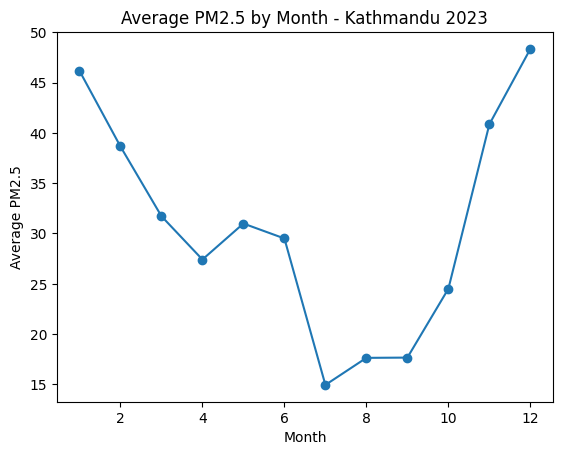

In [10]:
# Visualize the monthly pattern with a line chart
# marker='o' adds dots at each data point for clarity

df.groupby('month')['pm2_5'].mean().plot(kind='line', marker='o')
plt.title('Average PM2.5 by Month - Kathmandu 2023')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.show()

In [11]:
# Compare PM2.5 levels against WHO air quality safety threshold
# WHO guideline: 15 µg/m³ (used here as a reference point for "safe" air)
who_limit = 15

# Count how many hours exceeded the safe limit
unsafe_hours = df[df["pm2_5"] > who_limit].shape[0]
total_hours = df.shape[0]

# f-string lets you insert variable values directly into a sentence
# The f before the quotes tells Python "this string has variables inside curly braces."
print(f"Hours exceeding WHO limit: {unsafe_hours} out of {total_hours}")
print(f"Percentage: {(unsafe_hours/total_hours)*100:.1f}%")

Hours exceeding WHO limit: 14395 out of 17544
Percentage: 82.1%


#### FINDING: 82.1% of hours in 2023 exceeded WHO's safe PM2.5 threshold
##### -This means Kathmandu's air was unsafe more often than it was safe
##### -Strongest during winter months (matches earlier monthly trend finding)

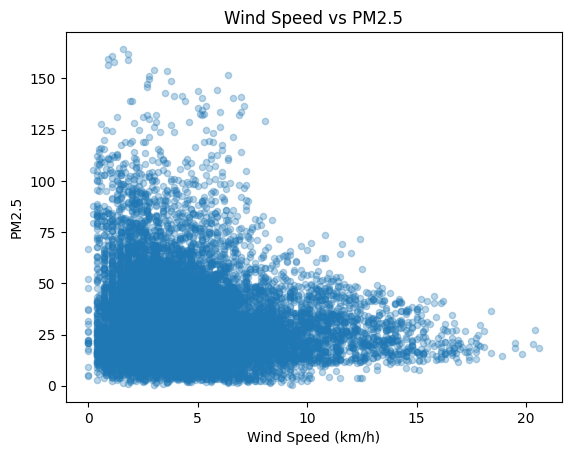

In [12]:
# Scatter plot: Wind speed vs PM2.5
# Testing whether wind disperses pollution
df.plot(kind='scatter', x='wind_speed_10m', y='pm2_5', alpha=0.3)
plt.title('Wind Speed vs PM2.5')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('PM2.5')
plt.show()

#### FINDING: 
##### -Low wind speed → higher PM2.5 (pollutants stay trapped, don't disperse)
##### -High wind speed → lower PM2.5 (wind disperses pollutants)
##### -This reinforces the seasonal finding: winter has stagnant, low-wind air
##### (temperature inversions trap pollution), monsoon brings stronger winds
##### and rain that actively clear the air

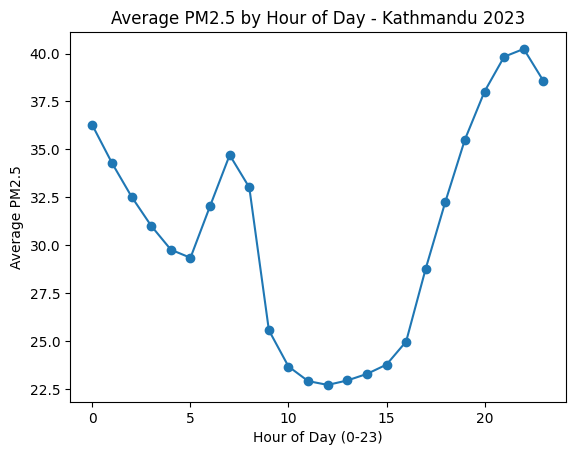

In [13]:
# Extract hour of day (0-23) from datetime
df["hour"] = df["time"].dt.hour

# Group by hour, calculate average PM2.5 to see daily pollution pattern
df.groupby("hour")["pm2_5"].mean().plot(kind="line", marker="o")
plt.title("Average PM2.5 by Hour of Day - Kathmandu 2023")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Average PM2.5")
plt.show()

#### FINDING: PM2.5 peaks at night (9pm-10pm), morning peak(7am), lowest between 10am-3pm
##### -Counter-intuitive at first : daytime has more traffic/activity but LOWER PM2.5
##### -Explanation: two competing factors : emissions vs dispersion
##### -Day: sun heats ground, warm air rises, creates vertical mixing that disperses pollutants even though emissions (traffic) are higher 
##### -Night: ground cools faster than air above it, creates a stable trapped layer pollutants accumulate even with lower emissions - nowhere to disperse      
##### -Same atmospheric principle as the seasonal winter finding, just on a daily cycle

In [14]:
# Correlation matrix - shows how all pollutants and weather variables relate to each other
correlation = df[["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", 
                   "sulphur_dioxide", "ozone", "temperature_2m", 
                   "relative_humidity_2m", "wind_speed_10m"]].corr()
print(correlation)

# Correlation:
# Close to 1 — strong positive relationship (both go up together)
# Close to -1 — strong negative relationship (one goes up, other goes down)
# Close to 0 — no real relationship

                         pm2_5      pm10  carbon_monoxide  nitrogen_dioxide  \
pm2_5                 1.000000  0.952177         0.620771          0.493972   
pm10                  0.952177  1.000000         0.581793          0.450204   
carbon_monoxide       0.620771  0.581793         1.000000          0.818402   
nitrogen_dioxide      0.493972  0.450204         0.818402          1.000000   
sulphur_dioxide       0.753975  0.640932         0.679694          0.528203   
ozone                -0.019743  0.059923        -0.441881         -0.627022   
temperature_2m       -0.522716 -0.472256        -0.681778         -0.562156   
relative_humidity_2m  0.045576  0.000371         0.173676          0.321942   
wind_speed_10m       -0.110932 -0.060674        -0.277660         -0.366355   

                      sulphur_dioxide     ozone  temperature_2m  \
pm2_5                        0.753975 -0.019743       -0.522716   
pm10                         0.640932  0.059923       -0.472256   
carbon_m

#### KEY FINDINGS from correlation with pm2_5:
##### -pm10 (0.95) : near-perfect correlation, both are particulate matter, same sources (dust, combustion, vehicle exhaust)            
##### -sulphur_dioxide (0.75) : strong link, suggests combustion/fossil fuel sources are a major driver of pollution                       
##### -carbon_monoxide (0.62) : also combustion-related, moderate link
##### -temperature (-0.52) : negative correlation, confirms seasonal finding: colder months (winter) have higher PM2.5                       
##### -wind_speed (-0.11) : weak negative here, but scatter plot showed clearer pattern at higher wind speeds specifically                

#### INTERPRETATION: PM2.5 pollution in Kathmandu is strongly linked to :
##### combustion sources (vehicles, fuel burning) rather than just natural dust, and is worse in colder, calmer conditions

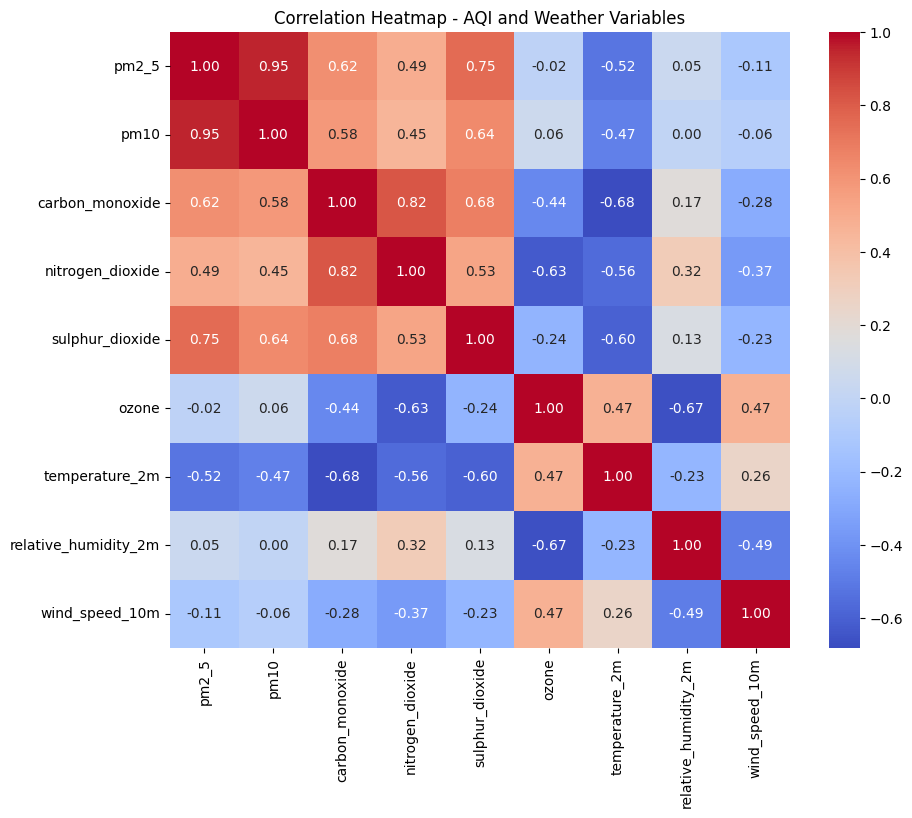

In [15]:
import seaborn as sns

# Correlation heatmap - visualizes the same correlation matrix from before
# but as colors instead of numbers, making patterns instantly visible
correlation = df[["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", 
                   "sulphur_dioxide", "ozone", "temperature_2m", 
                   "relative_humidity_2m", "wind_speed_10m"]].corr()

plt.figure(figsize=(10, 8))
# annot=True shows the actual correlation numbers on each cell
# cmap='coolwarm' - red for positive correlation, blue for negative
# fmt='.2f' rounds numbers to 2 decimal places for readability
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - AQI and Weather Variables')
plt.show()

#### FINDING: Visual confirmation of earlier correlation matrix
##### 1) pm10 and pm2_5 (0.95) : deep red, near-identical behavior (same particulate sources)
##### 2) sulphur_dioxide (0.75) and carbon_monoxide (0.62) also correlate fairly strongly with pm2_5.
##### -Both gases are byproducts of burning fossil fuels.
##### -Their correlation with pm2_5 suggests combustion (vehicles, industry, fuel burning)
##### is a major source of Kathmandu's air pollution - not just wind-blown dust
##### 3) temperature (-0.52) : moderate blue, confirms seasonal finding from a different angle 
##### (colder months = higher pollution)